Getting the Puska and Nieminen (1983) friction coefficient scaling law parameters from the paper:

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# The data is taken from tables 1-5 of Puska & Nieminen (1983)
# The first key is the density parameter r_s, the second key is
# the atomic number of the ion. The values are the friction parameter gamma.
Puska1983_data = {
    '1.5': {'1':0.310, '2': 0.755, '3':0.912, '4': 1.112, '5':1.417, '6':1.692, '7':1.777, '8':1.692,
            '9':1.346, '10':1.047, '11':0.815, '12':0.690, '13':0.697, '14':0.850, '15':1.146, '16':1.539, '17':1.975},
    '2.0': {'1':0.269, '2':0.427, '3':0.439, '4':0.557, '5':0.749, '6':0.874, '7':0.825, '8':0.637,
            '9':0.428, '10':0.267, '11':0.183, '12':0.199, '13':0.338, '14':0.580, '15':0.846, '16':1.062, '17':1.219, '26':0.788},
    '3.0': {'1':0.163, '2':0.135, '3':0.117, '4':0.191, '5':0.307, '6':0.346, '7':0.275, '8':0.167,
            '9':0.085, '10':0.034, '11':0.032, '12':0.108, '13':0.242, '14':0.348, '15':0.360, '17':0.234},
    '4.0': {'1':0.098, '2':0.047, '3':0.038, '4':0.111, '5':0.188, '6':0.199, '7':0.144, '8':0.080,
            '9':0.039, '10':0.008, '11':0.019, '12':0.087, '13':0.167, '14':0.196, '17':0.058},
    '5.0': {'1':0.059, '2':0.019, '3':0.023, '4':0.085, '5':0.131, '6':0.133, '7':0.094, '8':0.053,
            '9':0.027, '10':0.002, '11':0.023, '12':0.074, '13':0.121, '14':0.125, '17':0.028},
}

In [5]:
def fitting_function(x,a,b):
    return a * np.exp(-(x-1.5)/b)

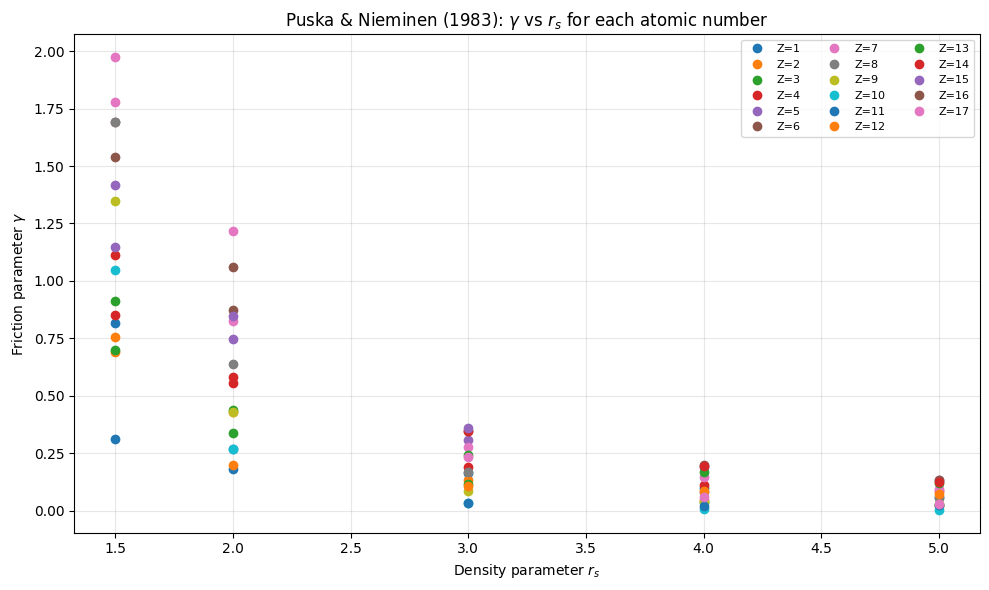

In [7]:
# Collect sorted density parameters (r_s) and all atomic numbers present in the dataset
r_s_values = sorted(float(rs) for rs in Puska1983_data.keys())
atomic_numbers = sorted({int(Z) for rs_data in Puska1983_data.values() for Z in rs_data.keys()})

plt.figure(figsize=(10, 6))

# Plot gamma vs r_s for each atomic number, skipping missing points
for Z in atomic_numbers:
    x_rs = []
    y_gamma = []
    for rs in r_s_values:
        gamma = Puska1983_data[str(rs)].get(str(Z))
        if gamma is not None:
            x_rs.append(rs)
            y_gamma.append(gamma)
    if x_rs:
        plt.plot(x_rs, y_gamma, marker='o', linewidth=0, label=f'Z={Z}')

plt.xlabel(r'Density parameter $r_s$')
plt.ylabel(r'Friction parameter $\gamma$')
plt.title(r'Puska & Nieminen (1983): $\gamma$ vs $r_s$ for each atomic number')
plt.grid(True, alpha=0.3)
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

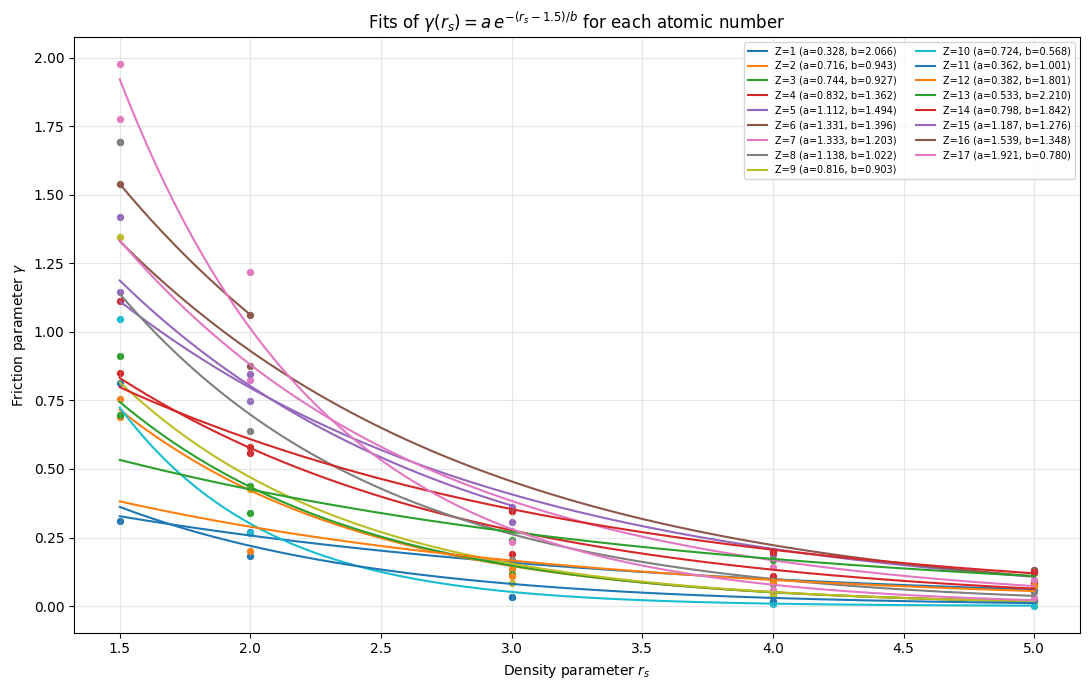

{1: (0.3276043263281516, 2.066385747052596),
 2: (0.7158613865149703, 0.9429436970558684),
 3: (0.7443619160131911, 0.9272950706097295),
 4: (0.8315970085322107, 1.3615157580334751),
 5: (1.1115108470032995, 1.494250626667162),
 6: (1.3305798299673828, 1.3961579271717137),
 7: (1.3334177019482423, 1.203087350343028),
 8: (1.1381631297698813, 1.0223503414344335),
 9: (0.8160679373789059, 0.9032992656284868),
 10: (0.7239788901025319, 0.5680233099421746),
 11: (0.3616329317939858, 1.0006497819331541),
 12: (0.38173077678333034, 1.8012025874223019),
 13: (0.5330363360699304, 2.2097038921354364),
 14: (0.7980920559717836, 1.8415254906491458),
 15: (1.1872251734606676, 1.2759447898879828),
 16: (1.5389999999999997, 1.3477854315191644),
 17: (1.9210663098124476, 0.7796435110543125)}

In [8]:
# Fit gamma(r_s) = a * exp(-(r_s - 1.5)/b) for each atomic number Z
fit_params = {}

plt.figure(figsize=(11, 7))

for Z in atomic_numbers:
	x_data, y_data = [], []
	for rs in r_s_values:
		g = Puska1983_data[str(rs)].get(str(Z))
		if g is not None:
			x_data.append(rs)
			y_data.append(g)

	if len(x_data) < 2:
		continue

	x = np.array(x_data, dtype=float)
	y = np.array(y_data, dtype=float)

	# Linearized fit: ln(y) = ln(a) - (x - 1.5)/b
	if np.any(y <= 0):
		continue

	m, c = np.polyfit(x - 1.5, np.log(y), 1)
	if np.isclose(m, 0.0):
		continue

	a = np.exp(c)
	b = -1.0 / m
	fit_params[Z] = (a, b)

	x_fit = np.linspace(x.min(), x.max(), 200)
	y_fit = fitting_function(x_fit, a, b)

	line, = plt.plot(x_fit, y_fit, lw=1.5, label=f"Z={Z} (a={a:.3f}, b={b:.3f})")
	plt.scatter(x, y, s=18, color=line.get_color())

plt.xlabel(r"Density parameter $r_s$")
plt.ylabel(r"Friction parameter $\gamma$")
plt.title(r"Fits of $\gamma(r_s)=a\,e^{-(r_s-1.5)/b}$ for each atomic number")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.show()

fit_params